In [2]:
import pandas as pd
import seaborn as sns

df = pd.read_csv("./data/Autos/autos.csv.bz2", encoding="ISO-8859-1")


df.dropna(inplace=True)

df.head()

,dateCrawled,name,seller,offerType,price,abtest,vehicleType,yearOfRegistration,gearbox,powerPS,model,kilometer,monthOfRegistration,fuelType,brand,notRepairedDamage,dateCreated,nrOfPictures,postalCode,lastSeen
3,2016-03-17 16:54:04,GOLF_4_1_4__3TÜRER,privat,Angebot,1500,test,kleinwagen,2001,manuell,75,golf,150000,6,benzin,volkswagen,nein,2016-03-17 00:00:00,0,91074,2016-03-17 17:40:17
4,2016-03-31 17:25:20,Skoda_Fabia_1.4_TDI_PD_Classic,privat,Angebot,3600,test,kleinwagen,2008,manuell,69,fabia,90000,7,diesel,skoda,nein,2016-03-31 00:00:00,0,60437,2016-04-06 10:17:21
5,2016-04-04 17:36:23,BMW_316i___e36_Limousine___Bastlerfahrzeug__Ex...,privat,Angebot,650,test,limousine,1995,manuell,102,3er,150000,10,benzin,bmw,ja,2016-04-04 00:00:00,0,33775,2016-04-06 19:17:07
6,2016-04-01 20:48:51,Peugeot_206_CC_110_Platinum,privat,Angebot,2200,test,cabrio,2004,manuell,109,2_reihe,150000,8,benzin,peugeot,nein,2016-04-01 00:00:00,0,67112,2016-04-05 18:18:39
7,2016-03-21 18:54:38,VW_Derby_Bj_80__Scheunenfund,privat,Angebot,0,test,limousine,1980,manuell,50,andere,40000,7,benzin,volkswagen,nein,2016-03-21 00:00:00,0,19348,2016-03-25 16:47:58


In [6]:
df["price"].max()

np.int64(99999999)

<Axes: xlabel='yearOfRegistration', ylabel='price'>

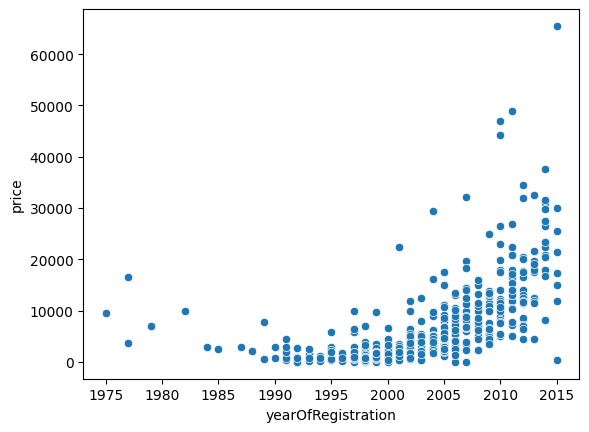

In [12]:
df_plot = df.sample(500)

# sns.scatterplot(data = df_plot, x="kilometer", y="price")
sns.scatterplot(data = df_plot, x="yearOfRegistration", y="price")

In [ ]:
df.groupby("vehicleType").agg(avgP = ("price", "mean"))

,avgP
vehicleType,
andere,4399.401806
bus,7465.588150
cabrio,11198.528816
coupe,21204.656474
kleinwagen,3111.622845
kombi,8488.303376
limousine,8155.998704
suv,13982.208078


In [19]:
df[df["price"] > 200000].head()

,dateCrawled,name,seller,offerType,price,abtest,vehicleType,yearOfRegistration,gearbox,powerPS,model,kilometer,monthOfRegistration,fuelType,brand,notRepairedDamage,dateCreated,nrOfPictures,postalCode,lastSeen
1846,2016-03-10 22:47:05,BMW_M1_Museumsfahrzeug_Neuwagenzustand_Glossy_...,privat,Angebot,579000,control,coupe,1980,manuell,277,andere,20000,12,benzin,bmw,nein,2016-03-10 00:00:00,0,60435,2016-03-23 10:45:27
10649,2016-04-05 09:36:18,Porsche_996_GT2_MK2_Clubsport,privat,Angebot,420000,control,coupe,2004,manuell,483,911,50000,4,benzin,porsche,nein,2016-04-05 00:00:00,0,81669,2016-04-07 12:15:38
20143,2016-03-18 00:55:53,Porsche_911R_Einer_von_911,privat,Angebot,1250000,test,coupe,2016,manuell,500,911,5000,3,benzin,porsche,nein,2016-03-17 00:00:00,0,70435,2016-03-20 04:48:27
20818,2016-03-14 13:56:15,Porsche_991_Carrera_S__50_Jahre_911___X51__430...,privat,Angebot,225000,test,coupe,2014,automatik,430,911,10000,1,benzin,porsche,nein,2016-03-14 00:00:00,0,78126,2016-04-05 15:15:57
21467,2016-03-19 19:45:02,Porsche_911_911R_1_of_20_ORIGINAL_R_nur_798KG!...,privat,Angebot,9999999,control,coupe,1967,manuell,215,911,50000,10,benzin,porsche,nein,2016-03-19 00:00:00,0,70435,2016-04-01 10:45:30


In [20]:
df_grouped = df.groupby("vehicleType").agg(avgP = ("price", "mean"))
df_grouped.index

Index(['andere', 'bus', 'cabrio', 'coupe', 'kleinwagen', 'kombi', 'limousine',
       'suv'],
      dtype='object', name='vehicleType')

<Axes: xlabel='vehicleType', ylabel='avgP'>

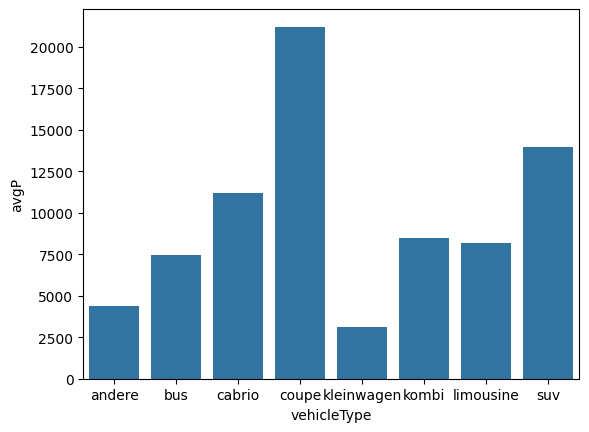

In [21]:
sns.barplot(x = df_grouped.index, y = df_grouped["avgP"])

In [24]:
df.corr?

Signature:
df.corr(
    method: 'CorrelationMethod' = 'pearson',
    min_periods: 'int' = 1,
    numeric_only: 'bool' = False,
) -> 'DataFrame'
Docstring:
Compute pairwise correlation of columns, excluding NA/null values.

Parameters
----------
method : {'pearson', 'kendall', 'spearman'} or callable
    Method of correlation:

    * pearson : standard correlation coefficient
    * kendall : Kendall Tau correlation coefficient
    * spearman : Spearman rank correlation
    * callable: callable with input two 1d ndarrays
        and returning a float. Note that the returned matrix from corr
        will have 1 along the diagonals and will be symmetric
        regardless of the callable's behavior.
min_periods : int, optional
    Minimum number of observations required per pair of columns
    to have a valid result. Currently only available for Pearson
    and Spearman correlation.
numeric_only : bool, default False
    Include only `float`, `int` or `boolean` data.

    .. versionadded::

In [23]:
df.corr(numeric_only=True)

,price,yearOfRegistration,powerPS,kilometer,monthOfRegistration,nrOfPictures,postalCode
price,1.000000,0.010434,0.008640,-0.013932,0.004747,NaN,0.001311
yearOfRegistration,0.010434,1.000000,0.102431,-0.395198,0.033529,NaN,0.046489
powerPS,0.008640,0.102431,1.000000,-0.016951,0.015070,NaN,0.026808
kilometer,-0.013932,-0.395198,-0.016951,1.000000,-0.006263,NaN,-0.032874
monthOfRegistration,0.004747,0.033529,0.015070,-0.006263,1.000000,NaN,0.004023
nrOfPictures,NaN,NaN,NaN,NaN,NaN,NaN,NaN
postalCode,0.001311,0.046489,0.026808,-0.032874,0.004023,NaN,1.000000


### Korrelation der Spalten
Beispiel: kilometer zu Preis -0.013932 -> bedeutet der Kilometerstand beeinflusst den Preis negativ

In [ ]:
df.corr(numeric_only=True)["price"].abs().sort_values(ascending=False)  # Zeigt die wichtigsten Einflussfaktoren zum Preis

price                  1.000000
kilometer              0.013932
yearOfRegistration     0.010434
powerPS                0.008640
monthOfRegistration    0.004747
postalCode             0.001311
nrOfPictures                NaN
Name: price, dtype: float64